# Suite 3 — Explainable AI & Feature Dynamics

**Goal:** verify the models read the physical priors and thermodynamic variables correctly post-rework.

SHAP beeswarms are recomputed here from the production tree models on the ML matrix. EBM interaction structure comes from the persisted `results/ebm_*_importance.csv`. TFT attention is embedded from the `explain_tft.py` artefacts (re-running the checkpoint is heavy and out of scope for a visualization notebook).

In [1]:
import os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Anchor to repo root so relative data/results paths work whether the notebook
# is launched from notebooks/ or the project root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.3,
})
FIG = "results/figures"
os.makedirs(FIG, exist_ok=True)

def save(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p)
    print("saved ->", p)
    return p

# Consistent model palette across every suite.
MODEL_ORDER = ["persistence", "climatology", "lightgbm", "xgboost", "ebm", "bilstm", "tft"]
PAL = dict(zip(MODEL_ORDER, sns.color_palette("colorblind", len(MODEL_ORDER))))
BASELINES = {"persistence", "climatology"}


In [2]:
import joblib, shap
from src.features.schema import FEATURE_COLS
mat = pd.read_parquet("data/processed/ml_training_matrix.parquet")
mat.index = pd.to_datetime(mat.index, utc=True)
X = mat[FEATURE_COLS]
Xs = X.sample(min(3000, len(X)), random_state=42)  # subsample for a legible beeswarm
print("SHAP background sample:", Xs.shape)

SHAP background sample: (3000, 9)


## 3a — SHAP beeswarm summaries (LightGBM & XGBoost, wind & solar)

saved -> results/figures/s3_shap_lightgbm_wind_beeswarm.png


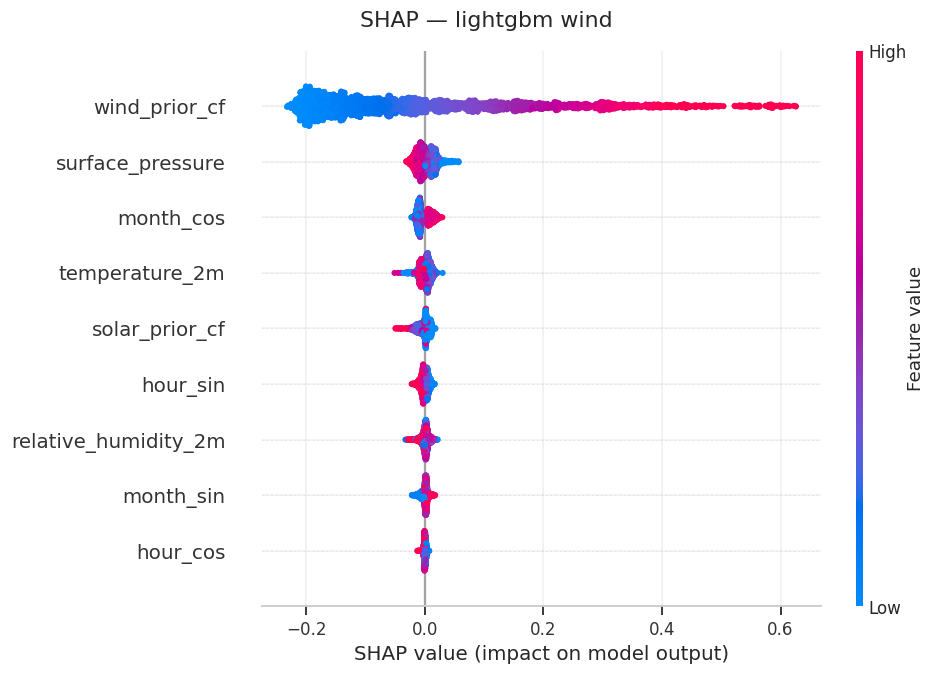

saved -> results/figures/s3_shap_lightgbm_solar_beeswarm.png


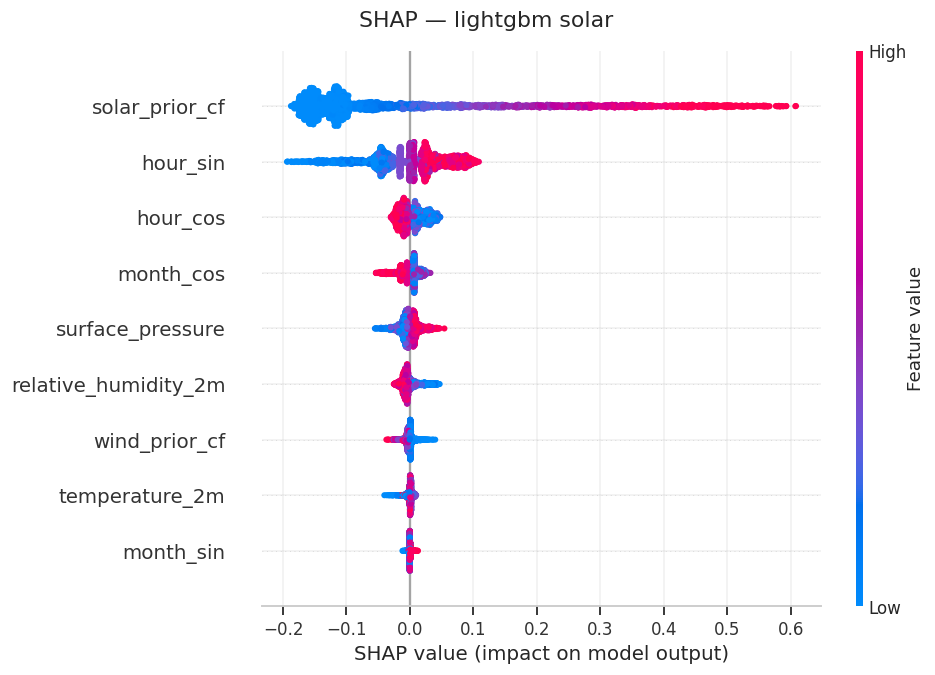

saved -> results/figures/s3_shap_xgboost_wind_beeswarm.png


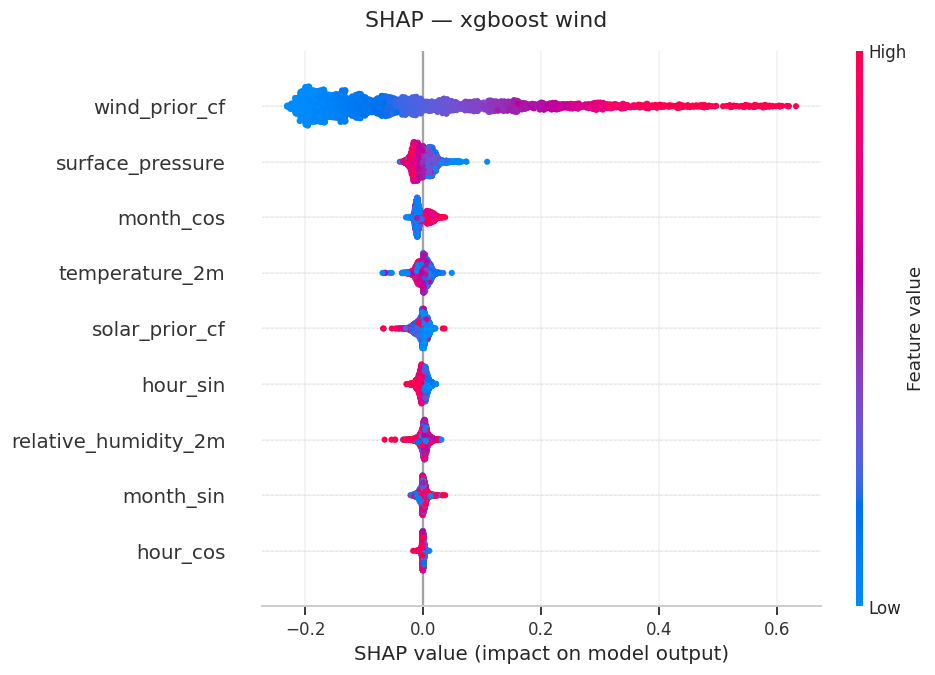

saved -> results/figures/s3_shap_xgboost_solar_beeswarm.png


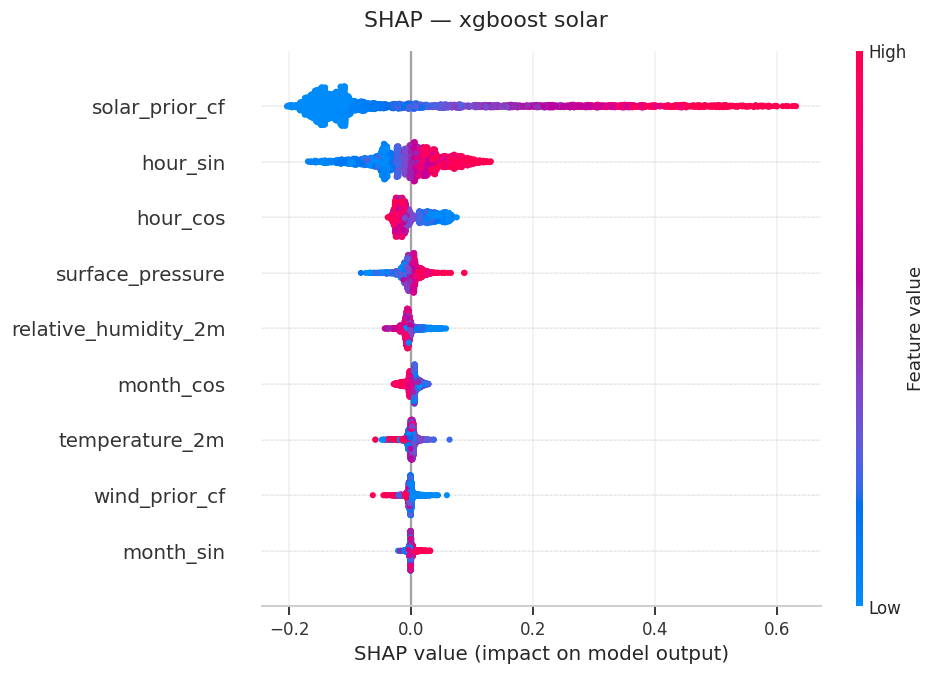

In [3]:
for model in ["lightgbm","xgboost"]:
    for tech in ["wind","solar"]:
        est = joblib.load(f"models/{model}_{tech}.pkl")
        explainer = shap.TreeExplainer(est)
        sv = explainer.shap_values(Xs)
        plt.figure(figsize=(9, 6))
        shap.summary_plot(sv, Xs, show=False, plot_size=None)
        fig = plt.gcf(); fig.suptitle(f"SHAP — {model} {tech}", y=1.02)
        save(fig, f"s3_shap_{model}_{tech}_beeswarm.png"); plt.show()

## 3b — EBM interaction heatmaps (pairwise feature interactions)

Diagonal = main effect, off-diagonal = pairwise interaction strength. Highlights the `wind_prior × solar_prior` and `prior × time-of-day` terms.

saved -> results/figures/s3_ebm_interaction_heatmap.png


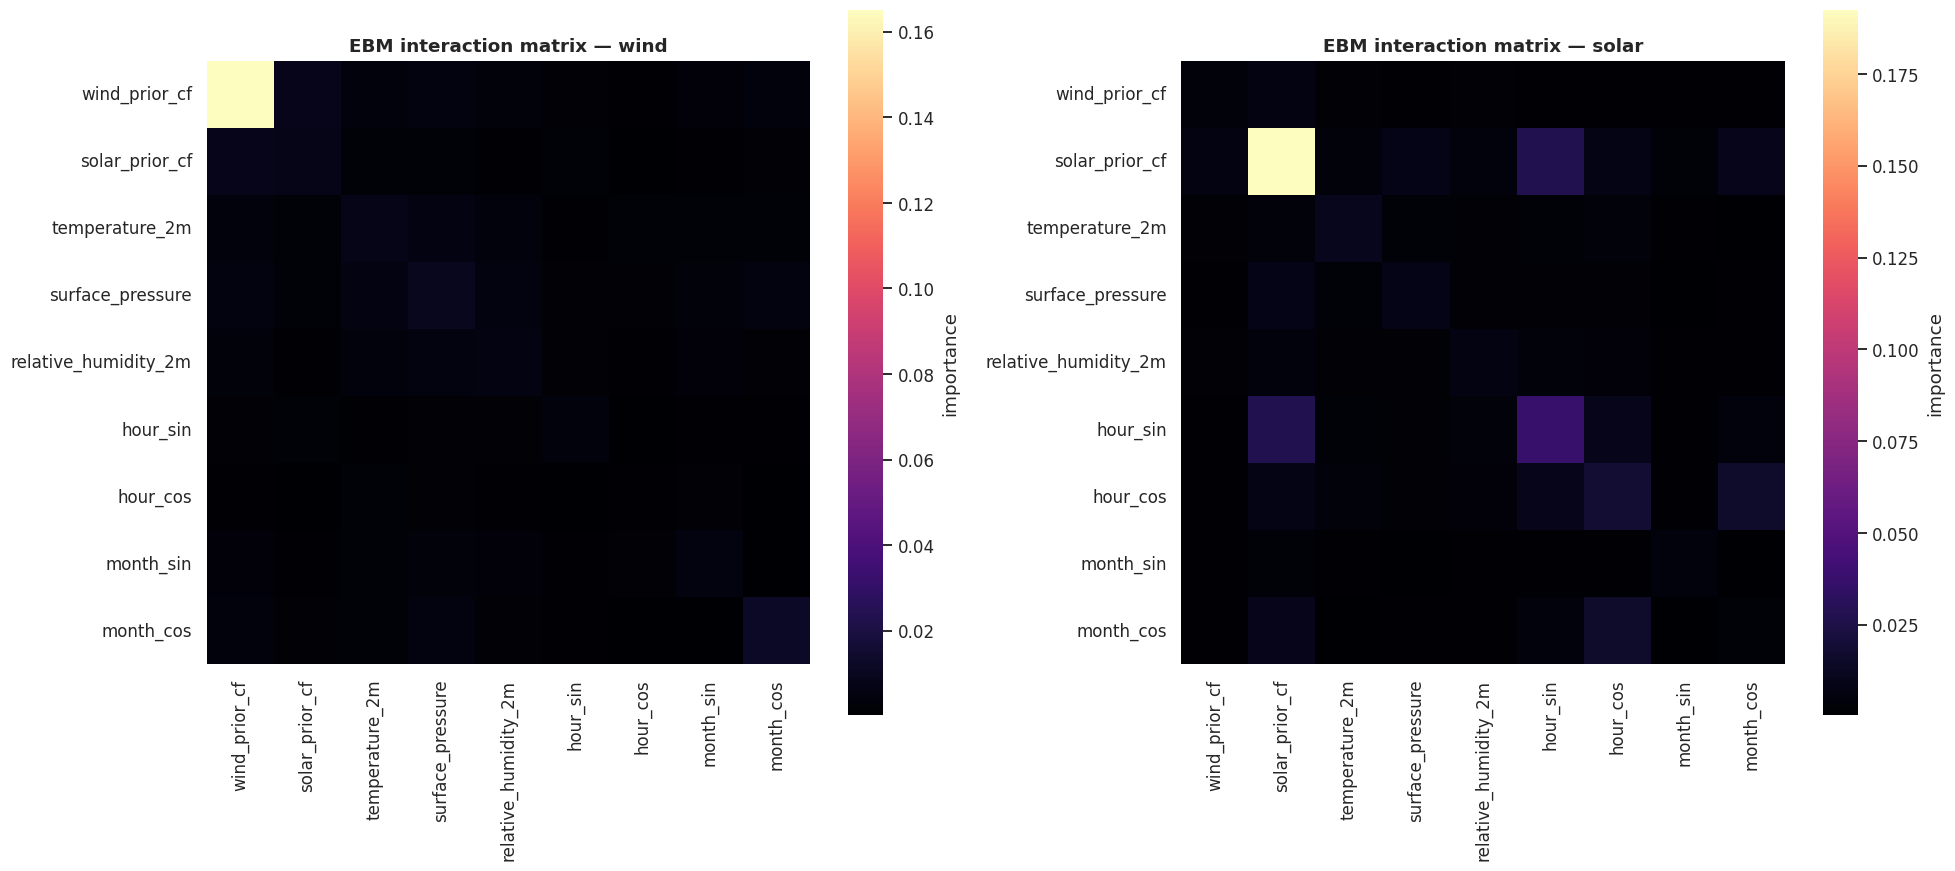

In [4]:
from src.features.schema import FEATURE_COLS
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, tech in zip(axes, ["wind","solar"]):
    imp = pd.read_csv(f"results/ebm_{tech}_importance.csv")
    M = pd.DataFrame(0.0, index=FEATURE_COLS, columns=FEATURE_COLS)
    for _, row in imp.iterrows():
        feat, score = row["Feature"], row["ImportanceScore"]
        if " & " in feat:
            a, b = feat.split(" & ")
            if a in M.index and b in M.columns:
                M.loc[a, b] = score; M.loc[b, a] = score
        elif feat in M.index:
            M.loc[feat, feat] = score
    sns.heatmap(M, ax=ax, cmap="magma", square=True, cbar_kws={"label":"importance"})
    ax.set_title(f"EBM interaction matrix — {tech}")
fig.tight_layout(); save(fig, "s3_ebm_interaction_heatmap.png"); plt.show()

## 3c — Top pairwise interactions (ranked)

saved -> results/figures/s3_ebm_top_interactions.png


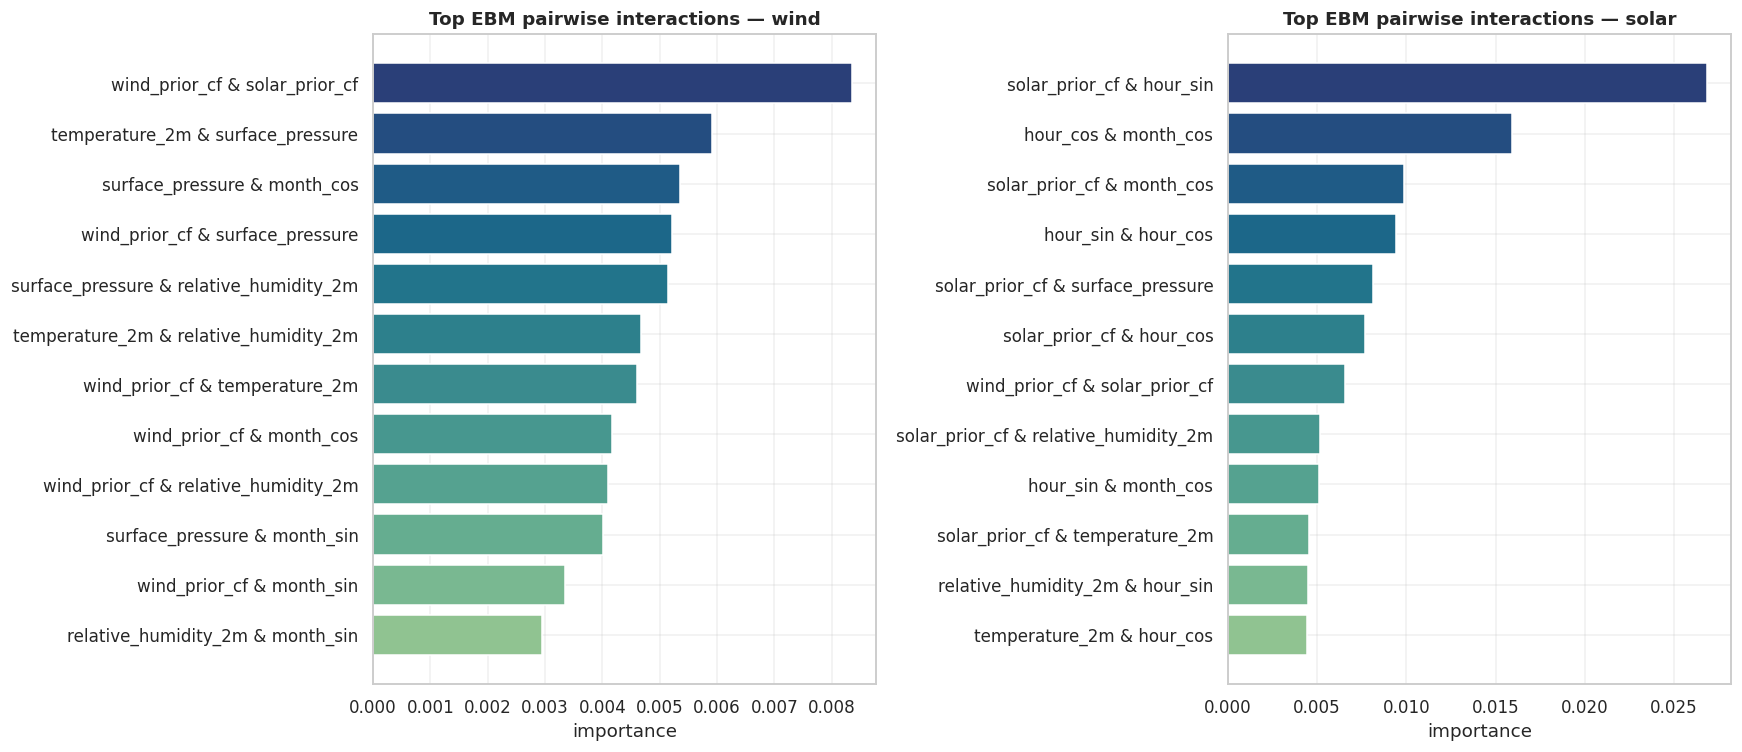

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, tech in zip(axes, ["wind","solar"]):
    imp = pd.read_csv(f"results/ebm_{tech}_importance.csv")
    pair = imp[imp["Feature"].str.contains(" & ")].head(12).iloc[::-1]
    ax.barh(pair["Feature"], pair["ImportanceScore"], color=sns.color_palette("crest", len(pair)))
    ax.set_title(f"Top EBM pairwise interactions — {tech}"); ax.set_xlabel("importance")
fig.tight_layout(); save(fig, "s3_ebm_top_interactions.png"); plt.show()

## 3d — TFT attention over time (from explain_tft.py artefacts)

Re-verify the solar 72-hour attention spike and wind autoregressive attention. These are embedded from the trained-checkpoint explanation run.

saved -> results/figures/s3_tft_attention.png


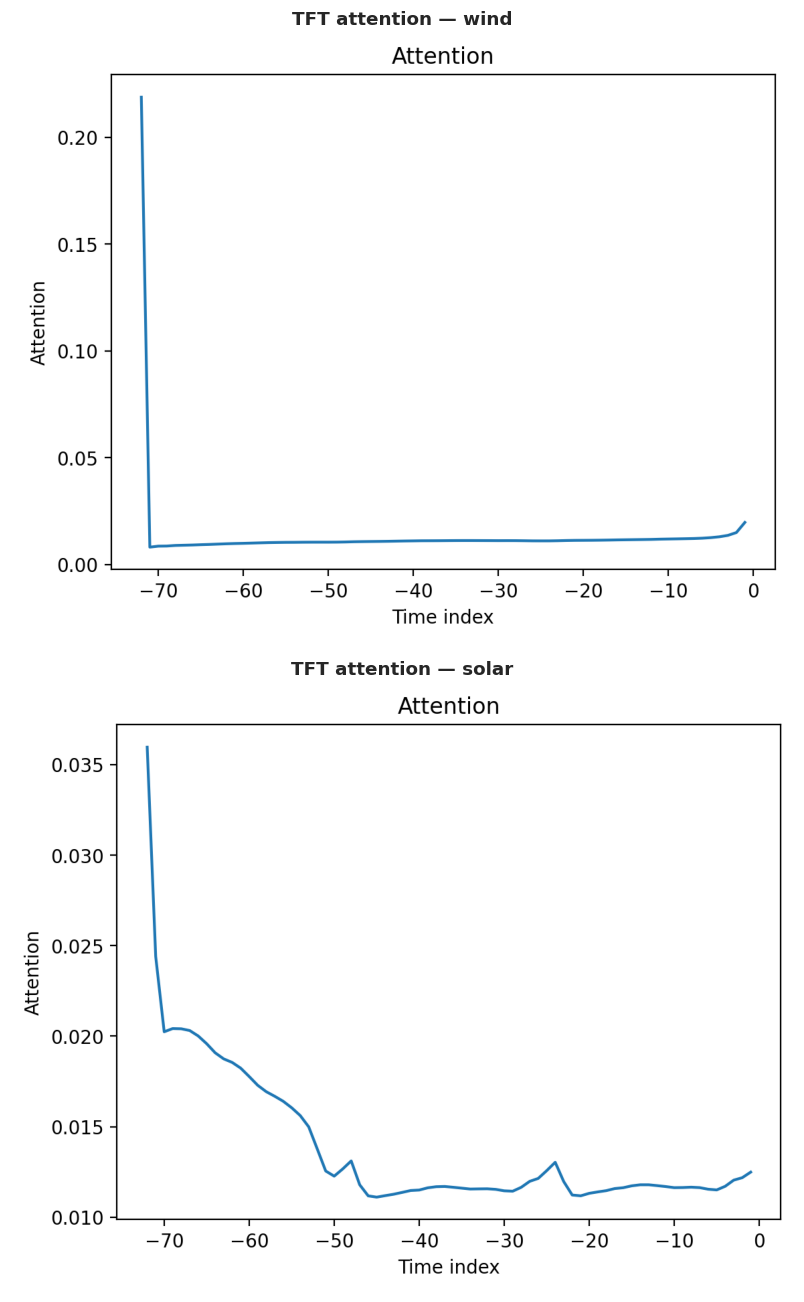

In [6]:
import matplotlib.image as mpimg, shutil
srcs = {"wind": "results/tft_wind_attention.png", "solar": "results/tft_solar_attention.png"}
fig, axes = plt.subplots(2, 1, figsize=(13, 12))
for ax, (tech, src) in zip(axes, srcs.items()):
    if os.path.exists(src):
        ax.imshow(mpimg.imread(src)); ax.set_title(f"TFT attention — {tech}")
        shutil.copy(src, os.path.join(FIG, f"s3_tft_{tech}_attention.png"))
    else:
        ax.text(0.5, 0.5, f"missing {src}\nrun: uv run -m src.models.explain_tft",
                ha="center", va="center")
    ax.axis("off")
fig.tight_layout(); save(fig, "s3_tft_attention.png"); plt.show()

## Feature ablation — the causal answer to RQ2

Everything above this point attributes skill to the physics prior via SHAP, EBM
importances and TFT attention. That triangulates well but stays *correlational*: a
feature can dominate an attribution ranking and still be replaceable by its
correlates. Retraining without it and measuring the error penalty is the causal,
falsifiable version of the same claim.

`src.evaluation.ablation` reruns the identical purged expanding-window CV under
three feature sets:

| variant | features |
|---|---|
| `full` | the production set (`schema.FEATURE_COLS`) |
| `no_prior` | both physics priors removed — raw weather + cyclical time only |
| `prior_only` | the technology's own prior, nothing else |

`prior_only` closes the loophole: with `no_prior` alone a reviewer can object that
the weather features are simply redundant with the prior, so removing it proves
nothing about the prior itself.

A fourth reference completes the picture — **`prior_raw`**, the physics prior used
directly as the forecast with no learner at all. Without it the table cannot
separate "the prior carries the signal" from "the learner corrects the prior",
since even `prior_only` still fits a model *on* the prior.

The four together answer RQ2 causally, and the two technologies answer it
**differently**:

| LightGBM, CV nMAE | wind | solar |
|---|---|---|
| `prior_raw` — physics only, no ML | 0.281 | 0.419 |
| `no_prior` — ML only, no physics | **0.580** | 0.270 |
| `full` — production | 0.204 | 0.197 |
| `prior_only` — ML on the prior alone | 0.191 | 0.316 |

On **wind** the raw physics prior with no machine learning whatsoever (0.281)
beats a fully trained LightGBM given every weather and time feature but no prior
(0.580) by more than a factor of two. On **solar** the ordering reverses: ML
without the prior (0.270) beats the raw prior (0.419). The prior is load-bearing
for both, but only for wind is it *irreplaceable* — which is consistent with the
physics, since the power curve already encodes the cubic wind-speed response
whereas the clear-sky solar prior still needs the learner to supply cloud
attenuation.

The penalty for removing the prior is consistent across architectures — wind
183-188% and solar 37-39% for LightGBM, XGBoost, EBM and TFT alike. That tightness
across gradient boosting, a glass-box GAM and a transformer is the point: it is a
property of the *feature*, not of one learner's inductive bias. (BiLSTM is the
outlier at +127% / +2.5%; its `full` model is already the weakest of the five, so
it was never extracting much from the prior to lose.)

The sharpest form of the result: the TFT's `no_prior` variant still sees 72 hours
of the target's own history through its encoder *and* the full weather set, and
still scores 0.562 on wind — twice the error of a bare power-curve calculation
with no learning at all (0.281).

Two things to state carefully:

1. On wind `prior_only` edges out `full` on average, but per fold it wins two
   clearly and loses two narrowly, so report the two as indistinguishable rather
   than as evidence that the weather features hurt.
2. The TFT's `prior_only` is not directly comparable to the trees', because the
   TFT always sees the target's past through its encoder whereas a tree given one
   feature sees literally one number per hour. Compare variants *within* a model
   family; the penalties stay comparable across families because each is measured
   against that model's own `full` baseline.

saved -> results/figures/s3_feature_ablation.png


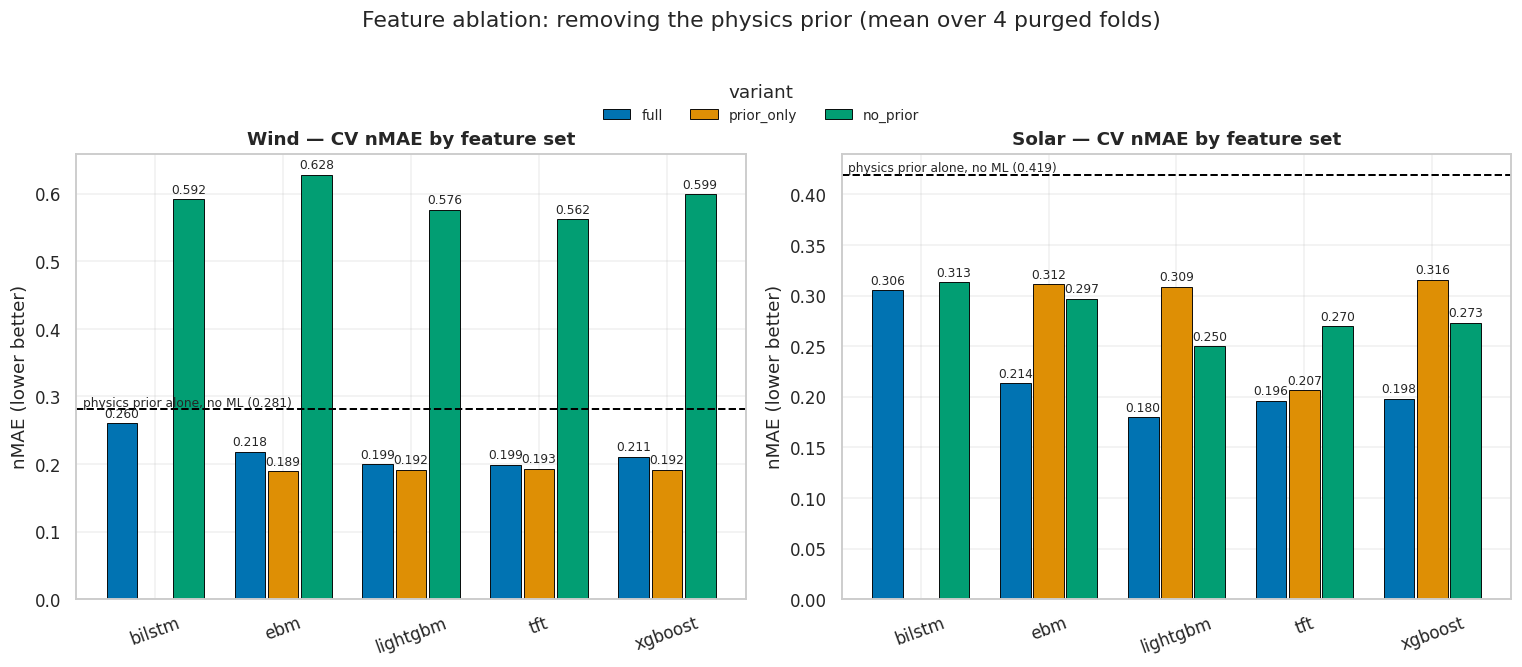

penalty_% = cost of removing the prior; prior_only_gap_% = cost of keeping ONLY it


variant                full  no_prior  prior_only  penalty_%  \
technology base                                                
solar      bilstm    0.3055    0.3132         NaN     2.5006   
           ebm       0.2137    0.2971      0.3115    39.0314   
           lightgbm  0.1799    0.2499      0.3090    38.9058   
           tft       0.1962    0.2696      0.2066    37.4377   
           xgboost   0.1981    0.2731      0.3157    37.8626   
wind       bilstm    0.2600    0.5916         NaN   127.5409   
           ebm       0.2181    0.6281      0.1893   188.0294   
           lightgbm  0.1995    0.5764      0.1915   188.9461   
           tft       0.1989    0.5623      0.1930   182.7179   
           xgboost   0.2110    0.5991      0.1917   183.8801   

variant              prior_only_gap_%  prior_raw  ml_gain_vs_raw_%  
technology base                                                     
solar      bilstm                 NaN     0.4194          -27.1508  
           ebm                45.8045     0.4194          -49.0523  
           lightgbm           71.7522     0.4194          -57.1086  
           tft                 5.3040     0.4194          -53.2247  
           xgboost            59.3899     0.4194          -52.7737  
wind       bilstm                 NaN     0.2812           -7.5518  
           ebm               -13.1917     0.2812          -22.4682  
           lightgbm           -3.9721     0.2812          -29.0777  
           tft                -2.9543     0.2812          -29.2841  
           xgboost            -9.1668     0.2812          -24.9606

In [7]:
from src.evaluation.ablation import summarise

abl = pd.read_csv("results/ablation_metrics.csv")
abl = abl[abl["scale"] == "cf"]
VAR_ORDER = ["full", "prior_only", "no_prior"]
VPAL = dict(zip(VAR_ORDER, sns.color_palette("colorblind", 10)[:3]))


def split_name(m):
    for v in sorted(VAR_ORDER, key=len, reverse=True):
        if m.endswith("_" + v):
            return m[: -(len(v) + 1)], v
    return m, "unknown"


abl[["base", "variant"]] = [split_name(m) for m in abl["model"]]
agg = (abl[abl["variant"] != "unknown"]
       .groupby(["technology", "base", "variant"])["nmae"].mean().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
for ax, tech in zip(axes, ["wind", "solar"]):
    sub = agg[agg["technology"] == tech]
    bases = sorted(sub["base"].unique())
    w = 0.26
    for k, v in enumerate(VAR_ORDER):
        vals = [sub[(sub["base"] == b) & (sub["variant"] == v)]["nmae"].mean() for b in bases]
        bars = ax.bar(np.arange(len(bases)) + (k - 1) * w, vals, w * 0.92,
                      color=VPAL[v], edgecolor="black", linewidth=0.6, label=v)
        ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
    # The learner-free reference: any bar above this line is beaten by the bare
    # physics prior. On wind, `no_prior` is — which is the headline of the section.
    raw = abl[(abl["model"] == "physics_prior_raw") & (abl["technology"] == tech)]["nmae"].mean()
    ax.axhline(raw, color="black", linestyle="--", linewidth=1.3)
    ax.annotate(f"physics prior alone, no ML ({raw:.3f})", xy=(0.01, raw), xycoords=("axes fraction", "data"),
                fontsize=8, va="bottom")
    ax.set_xticks(np.arange(len(bases))); ax.set_xticklabels(bases, rotation=20)
    ax.set_title(f"{tech.title()} — CV nMAE by feature set")
    ax.set_ylabel("nMAE (lower better)")
# Figure-level legend: an in-axes one collides with the tall no_prior bars.
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, title="variant", fontsize=9, ncol=3, loc="upper center",
           bbox_to_anchor=(0.5, 1.00), frameon=False)
fig.suptitle("Feature ablation: removing the physics prior (mean over 4 purged folds)", y=1.10)
fig.tight_layout(); save(fig, "s3_feature_ablation.png"); plt.show()

# The headline RQ2 number: the nMAE penalty for dropping the prior.
tab = summarise()
print("penalty_% = cost of removing the prior; prior_only_gap_% = cost of keeping ONLY it")
tab